In [ ]:
![image.png](attachment:image.png)

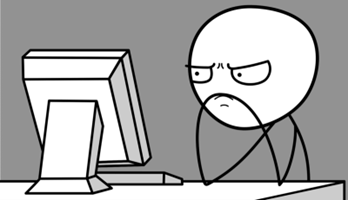

Para ejercitarte y afianzar lo aprendido sobre **Features**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.model_selection import train_test_split

### Ejercicio 1

Carga el dataset de advertising, convierte la variable edad a numérica y haz el split en train y test como hicimos en la tanda de ejercicios anterior (usa una semilla de 42 y un reparto 80-20)

In [2]:
df = pd.read_csv("./data/advertising_ml.csv")

In [6]:
df["Age"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Age
Non-Null Count  Dtype 
--------------  ----- 
1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


In [3]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [11]:
df["Age"] = (
    df["Age"]
    .str.extract(r"(\d+)")
    .astype(float)
)


### Ejercicio 2

Aunque es algo que debemos hacer en la parte del EDA del dataset para no sobrecargar los ejercicios anteriores hemos dejado para este momento el análisis del target. Muestra las frecuencias absolutas y frecuencias relativas del target (no hace falta que hagas un gráfico)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   float64
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 78.3+ KB


In [16]:
df["Clicked on Ad"].value_counts()

Clicked on Ad
0    500
1    500
Name: count, dtype: int64

In [17]:
df["Clicked on Ad"].value_counts()/100

Clicked on Ad
0    5.0
1    5.0
Name: count, dtype: float64

### Ejercicio 3

Vamos a tratar las categóricas que se nos quedaron en el tintero: "City" y "Country" (recuerda que descartamos "Male" por su distribución de valores respecto al target que vimos en la gráfica del último ejercicio). Vuelve a calcular la cardinalidad de "City" y los valores que más se repiten:

In [20]:
df["City"].nunique()

969

In [26]:
df["City"].value_counts().head(10)

City
Lisamouth          3
Williamsport       3
West Amanda        2
East Timothy       2
Lake Patrick       2
Wrightburgh        2
New Sheila         2
Port Juan          2
New Jessicaport    2
Millerbury         2
Name: count, dtype: int64

Independientemente de lo que hayas visto, descartamos "City" (mira la solución para una argumentación). Y nos centramos en Country.

### Ejercicio 4

Para "Country" obtén las 5 ciudades que más se repiten y para estas las distribución de valores de "Clicked on Ad" 

In [27]:
df["Country"].nunique()

237

In [29]:
df["Country"].value_counts().head(5)

Country
Czech Republic    9
France            9
Senegal           8
Peru              8
Greece            8
Name: count, dtype: int64

In [30]:
top_countries = ["Czech Republic", "France", "Senegal", "Peru", "Greece"]

In [31]:
df_top = df[df["Country"].isin(top_countries)]

In [32]:
df_top.groupby("Country")["Clicked on Ad"].value_counts()

Country         Clicked on Ad
Czech Republic  0                5
                1                4
France          1                5
                0                4
Greece          0                5
                1                3
Peru            1                5
                0                3
Senegal         1                5
                0                3
Name: count, dtype: int64

### Ejercicio 5

Vamos a incluir "Country" y como es categórica debeos hacer una conversión a numérica. De los dos tipos de paso a numérica de una categórica, vamos a hacer un "One-hot encoding". Hazlo usando la función `get_dummies` de pandas. ¿Por qué crees que hacemos esta conversión?

In [33]:
pd.get_dummies(train_set, columns=["Country"]).head()


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Timestamp,Clicked on Ad,ordinal_age,...,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela,Country_Vietnam,Country_Wallis and Futuna,Country_Western Sahara,Country_Yemen,Country_Zambia,Country_Zimbabwe
29,76.02,22 años,46179.97,209.82,Business-focused value-added definition,West Guybury,0,2016-01-27 12:38:16,0,6.0,...,False,False,False,False,False,False,False,False,False,False
535,78.76,32 years,70012.83,208.02,Managed attitude-oriented Internet solution,East Valerie,1,2016-04-20 10:04:29,0,27.0,...,True,False,False,False,False,False,False,False,False,False
695,73.49,38 years,67132.46,244.23,Organic 3rdgeneration encryption,Mosleyburgh,0,2016-02-14 11:36:08,0,39.0,...,False,False,True,False,False,False,False,False,False,False
557,79.67,28 años,58576.12,226.79,Total grid-enabled application,Charlesbury,0,2016-07-20 01:56:33,0,18.0,...,False,False,False,False,False,False,False,False,False,False
836,49.21,46 years,49206.40,115.60,Realigned 24/7 core,Carterland,0,2016-02-28 03:34:35,1,55.0,...,False,False,False,False,False,False,False,False,False,False


In [34]:
pd.get_dummies(train_set, columns=["Country"], dtype= int).head()


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Timestamp,Clicked on Ad,ordinal_age,...,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela,Country_Vietnam,Country_Wallis and Futuna,Country_Western Sahara,Country_Yemen,Country_Zambia,Country_Zimbabwe
29,76.02,22 años,46179.97,209.82,Business-focused value-added definition,West Guybury,0,2016-01-27 12:38:16,0,6.0,...,0,0,0,0,0,0,0,0,0,0
535,78.76,32 years,70012.83,208.02,Managed attitude-oriented Internet solution,East Valerie,1,2016-04-20 10:04:29,0,27.0,...,1,0,0,0,0,0,0,0,0,0
695,73.49,38 years,67132.46,244.23,Organic 3rdgeneration encryption,Mosleyburgh,0,2016-02-14 11:36:08,0,39.0,...,0,0,1,0,0,0,0,0,0,0
557,79.67,28 años,58576.12,226.79,Total grid-enabled application,Charlesbury,0,2016-07-20 01:56:33,0,18.0,...,0,0,0,0,0,0,0,0,0,0
836,49.21,46 years,49206.40,115.60,Realigned 24/7 core,Carterland,0,2016-02-28 03:34:35,1,55.0,...,0,0,0,0,0,0,0,0,0,0


### Ejercicio 6

Ahora vamos a hacer el escalado de las features numéricas que habíamos seleccionado en los ejercicios anteriores:

["Age","Area Income","Daily Internet Usage","Daily Time Spent on Site"]

En este caso vamos a emplear la standardization (revisa la píldora y aplicala a las variables anteriores). Muestra la media y la desviación estándar del resultado.

In [39]:
from sklearn.preprocessing import StandardScaler

features_num = ["Age","Area Income","Daily Internet Usage","Daily Time Spent on Site"]
std_scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_set[features_num])
resultado_standardization = pd.DataFrame(std_scaler.fit_transform(train_set[features_num]),columns = features_num)
resultado_standardization.head()




NameError: name 'scaler' is not defined

NOTA FINAL: Este dataset pide más transformaciones entre otras la de las fechas en franjas (horas, días de la semana, etc) pero lo dejamos para sprints posteriores. 